In [1]:
from PIL import Image
import matplotlib.pyplot as plt
import os
import rasterio
import numpy as np
from scipy.ndimage import gaussian_filter
from typing import List, Tuple

In [2]:
DATA_PATH = r"Data/"

In [3]:
pre_image_parser = os.listdir(DATA_PATH + "train/pre-event/")
post_image_parser = os.listdir(DATA_PATH + "train/post-event/")
target_image_parser = os.listdir(DATA_PATH + "train/target/")
print(len(pre_image_parser))

2781


(3, 1024, 1024)
(1, 1024, 1024)
(1, 1024, 1024)


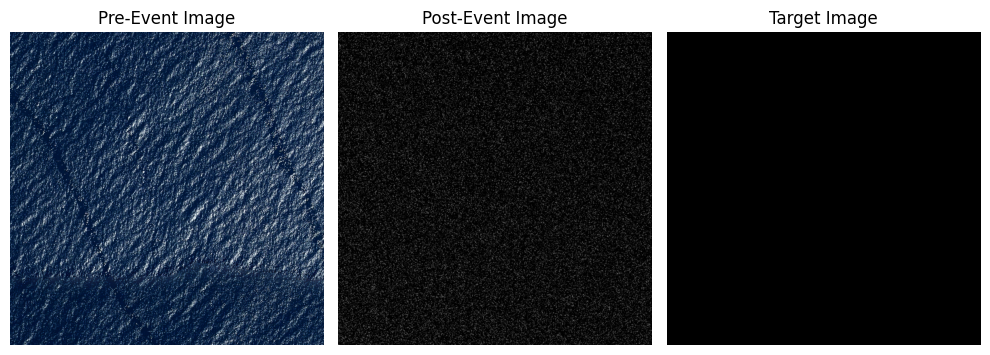

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(10, 5))

# 2123 - best
pre_path = DATA_PATH + "train/pre-event/" + pre_image_parser[1234]
post_path = DATA_PATH + "train/post-event/" + post_image_parser[1234]
target_path = DATA_PATH + "train/target/" + target_image_parser[1234]

with rasterio.open(pre_path) as pre_src:
    arr_1 = pre_src.read()
    print(arr_1.shape)
    if arr_1.shape[0] >= 3:
        pre_img = Image.fromarray(arr_1[:3].transpose(1, 2, 0))
        ax[0].imshow(pre_img)
    else:
        ax[0].imshow(arr_1[0], cmap="gray")
    ax[0].set_title("Pre-Event Image")
    ax[0].axis("off")

with rasterio.open(post_path) as post_src:
    arr_2 = post_src.read()
    print(arr_2.shape)
    if arr_2.shape[0] >= 3:
        post_img = Image.fromarray(arr_2[:3].transpose(1, 2, 0))
        ax[1].imshow(post_img)
        ax[1].set_title("Post-Event Image")
    else:
        ax[1].imshow(arr_2[0], cmap="gray")
        ax[1].set_title("Post-Event Image")
    ax[1].axis("off")

with rasterio.open(target_path) as target_src:
    arr_3 = target_src.read()
    print(arr_3.shape)
    if arr_3.shape[0] >= 3:
        target_img = Image.fromarray(arr_3[:3].transpose(1, 2, 0))
        ax[2].imshow(target_img)
    else:
        ax[2].imshow(arr_3[0], cmap="gray")
    ax[2].set_title("Target Image")
    ax[2].axis("off")
plt.tight_layout()
plt.show()

In [ ]:
### Frequency Analysis

'''
Frequency analysis using Fourier transforms showed that SAR images exhibit slightly lower low-frequency energy ratios compared to EO images, indicating higher high-frequency content.
However, this is attributed to speckle noise inherent in SAR imagery rather than meaningful structural detail.

Visual inspection of frequency spectra confirms that SAR high-frequency components are more uniformly distributed and noisy, 
whereas EO images retain more structured frequency patterns corresponding to edges and textures.

This highlights an important distinction: frequency magnitude alone does not differentiate between signal and noise, 
and motivates the need for noise-robust feature extraction when working with SAR data.

'''

def compute_fft(image):
    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)  # center low freq
    magnitude = np.log(np.abs(fshift) + 1)
    return magnitude

def frequency_energy_ratio(fft_mag):
    h, w = fft_mag.shape
    center = fft_mag[h//4:3*h//4, w//4:3*w//4]
    
    low_energy = np.sum(center)
    total_energy = np.sum(fft_mag)
    
    return low_energy / total_energy

EO Energy Ratio: 0.2996
SAR Energy Ratio: 0.2763


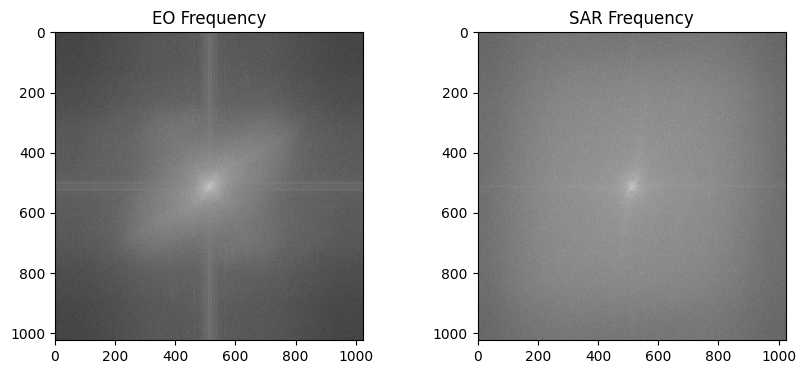

In [38]:
eo_fft = compute_fft(arr_1[0])
sar_fft = compute_fft(arr_2[0])

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("EO Frequency")
plt.imshow(eo_fft, cmap='gray')

plt.subplot(1,2,2)
plt.title("SAR Frequency")
plt.imshow(sar_fft, cmap='gray')


eo_energy_ratio = frequency_energy_ratio(eo_fft)
sar_energy_ratio = frequency_energy_ratio(sar_fft)

print(f"EO Energy Ratio: {eo_energy_ratio:.4f}")
print(f"SAR Energy Ratio: {sar_energy_ratio:.4f}")

EO Energy Ratio: 0.2996
Transformed-SAR Energy Ratio: 0.2892


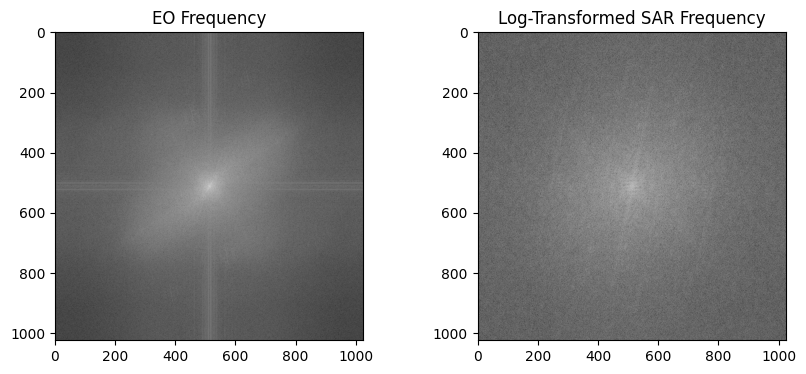

In [36]:
### Log Transformation

normalized_sar = arr_2 / 255.0
inverse_log_sar = np.exp(normalized_sar) - 1
transformed_sar = np.clip(inverse_log_sar, 0, 255).astype(np.uint8)

transformed_sar = compute_fft(transformed_sar[0])
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("EO Frequency")
plt.imshow(eo_fft, cmap='gray')

plt.subplot(1,2,2)
plt.title("Log-Transformed SAR Frequency")
plt.imshow(transformed_sar, cmap='gray')

eo_energy_ratio = frequency_energy_ratio(eo_fft)
t_sar_energy_ratio = frequency_energy_ratio(transformed_sar)

print(f"EO Energy Ratio: {eo_energy_ratio:.4f}")
print(f"Transformed-SAR Energy Ratio: {t_sar_energy_ratio:.4f}")


EO Energy Ratio: 0.2996
Gaussian Blured-SAR Energy Ratio: 0.3323


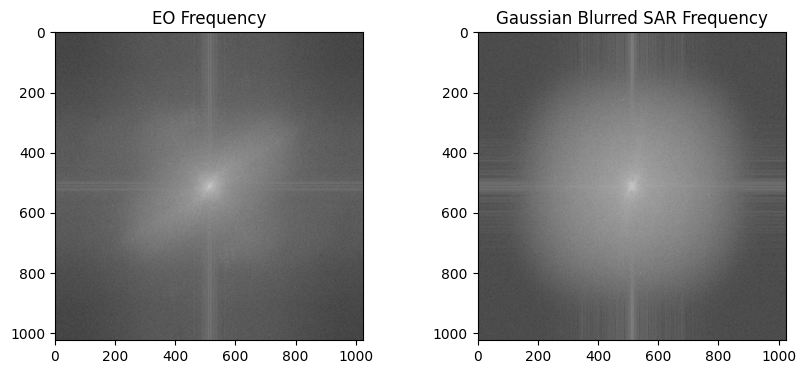

In [ ]:
### Using Gaussian Bluring to remove Speckle noise

gblur_sar = gaussian_filter(arr_2, sigma=1)
gblur_sar = np.clip(gblur_sar, 0, 255).astype(np.uint8)

gblur_sar = compute_fft(gblur_sar[0])
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("EO Frequency")
plt.imshow(eo_fft, cmap='gray')

plt.subplot(1,2,2)
plt.title("Gaussian Blurred SAR Frequency")
plt.imshow(gblur_sar, cmap='gray')

eo_energy_ratio = frequency_energy_ratio(eo_fft)
gblur_sar_energy_ratio = frequency_energy_ratio(gblur_sar)

print(f"EO Energy Ratio: {eo_energy_ratio:.4f}")
print(f"Gaussian Blured-SAR Energy Ratio: {gblur_sar_energy_ratio:.4f}")

(3, 1024, 1024)
(1, 1024, 1024)
(1, 1024, 1024)


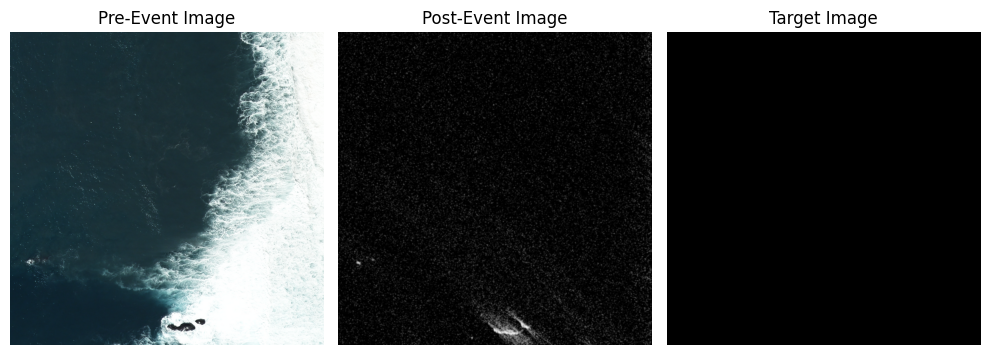

In [46]:
fig, ax = plt.subplots(1, 3, figsize=(10, 5))

IMAGE_INDEX = 681
pre_path = DATA_PATH + "train/pre-event/" + pre_image_parser[IMAGE_INDEX]
post_path = DATA_PATH + "train/post-event/" + post_image_parser[IMAGE_INDEX]
target_path = DATA_PATH + "train/target/" + target_image_parser[IMAGE_INDEX]

with rasterio.open(pre_path) as pre_src:
    arr_1 = pre_src.read()
    print(arr_1.shape)
    if arr_1.shape[0] >= 3:
        pre_img = Image.fromarray(arr_1[:3].transpose(1, 2, 0))
        ax[0].imshow(pre_img)
    else:
        ax[0].imshow(arr_1[0], cmap="gray")
    ax[0].set_title("Pre-Event Image")
    ax[0].axis("off")

with rasterio.open(post_path) as post_src:
    arr_2 = post_src.read()
    arr_2 = gaussian_filter(arr_2, sigma=1)
    print(arr_2.shape)
    if arr_2.shape[0] >= 3:
        post_img = Image.fromarray(arr_2[:3].transpose(1, 2, 0))
        ax[1].imshow(post_img)
        ax[1].set_title("Post-Event Image")
    else:
        ax[1].imshow(arr_2[0], cmap="gray")
        ax[1].set_title("Post-Event Image")
    ax[1].axis("off")

with rasterio.open(target_path) as target_src:
    arr_3 = target_src.read()
    print(arr_3.shape)
    if arr_3.shape[0] >= 3:
        target_img = Image.fromarray(arr_3[:3].transpose(1, 2, 0))
        ax[2].imshow(target_img)
    else:
        ax[2].imshow(arr_3[0], cmap="gray")
    ax[2].set_title("Target Image")
    ax[2].axis("off")
plt.tight_layout()
plt.show()

##### ✅ Do:
*Use*:
- Learnable filters (CNNs)
- Attention mechanisms
- Multi-scale features

In [62]:
pre_files = sorted(os.listdir(DATA_PATH + "train/pre-event/"))
post_files = sorted(os.listdir(DATA_PATH + "train/post-event/"))
target_files = sorted(os.listdir(DATA_PATH + "train/target/"))

def get_valid_mask(arr, nodata=None):
    if nodata is None:
        valid = np.any(arr != 0, axis = 0)
    else:
        valid = np.all(arr != nodata, axis=0)
    return valid

def compute_sample_stats(pre_path, post_path, target_path):
    with rasterio.open(pre_path) as s1, rasterio.open(post_path) as s2, rasterio.open(target_path) as st:
        pre = s1.read()
        post = s2.read()
        target = st.read(1)

        pre_valid = get_valid_mask(pre, s1.nodata)
        post_valid = get_valid_mask(post_files, s2.nodata)
        valid = pre_valid & post_valid

        valid_ratio = valid.mean()
        change = (target > 0) & valid
        change_ratio = change.sum()/max(valid.sum(), 1)

        return valid_ratio, change_ratio

VALID_THR = 0.30
CHANGE_THR = 0.0005

keep_indexes = []
drop_indexes = []

for i, (x, y ,z) in enumerate (zip(pre_files, post_files, target_files)):
    pre_path = f"{DATA_PATH}train/pre-event/{x}"
    post_path = f"{DATA_PATH}train/post-event/{y}"
    target_path = f"{DATA_PATH}train/target/{z}"

    valid_ratio, change_ratio = compute_sample_stats(pre_path, post_path, target_path)

    if valid_ratio < VALID_THR:
        drop_indexes.append((i, "low_valid", valid_ratio, change_ratio))
        continue
    if change_ratio < CHANGE_THR:
        drop_indexes.append((i, "minimal_changes", valid_ratio, change_ratio))
        continue
    keep_indexes.append((i, valid_ratio, change_ratio))


print(f"Kept : {len(keep_indexes)}({(len(keep_indexes)/2781)*100:.2f}%), Dropped: {len(drop_indexes)}({(len(drop_indexes)/2781)*100:.2f}%)")


Kept : 2105(75.69%), Dropped: 676(24.31%)


In [63]:
drop_indexes

[(0,
  'low_valid',
  np.float64(0.17948150634765625),
  np.float64(0.21049946865037195)),
 (4,
  'low_valid',
  np.float64(0.12327384948730469),
  np.float64(0.004448329748882115)),
 (35, 'low_valid', np.float64(0.05801200866699219), np.float64(0.0)),
 (48, 'minimal_changes', np.float64(0.4746818542480469), np.float64(0.0)),
 (71, 'minimal_changes', np.float64(1.0), np.float64(0.0)),
 (74, 'minimal_changes', np.float64(0.7869558334350586), np.float64(0.0)),
 (75, 'low_valid', np.float64(0.18755435943603516), np.float64(0.0)),
 (76, 'minimal_changes', np.float64(0.9067955017089844), np.float64(0.0)),
 (80, 'minimal_changes', np.float64(1.0), np.float64(0.0)),
 (82, 'low_valid', np.float64(0.0757150650024414), np.float64(0.0)),
 (83, 'low_valid', np.float64(0.1382884979248047), np.float64(0.0)),
 (87, 'minimal_changes', np.float64(0.8806657791137695), np.float64(0.0)),
 (88, 'low_valid', np.float64(0.1110391616821289), np.float64(0.0)),
 (89, 'low_valid', np.float64(0.09651470184326172)

(3, 1024, 1024)
(1, 1024, 1024)
(1, 1024, 1024)


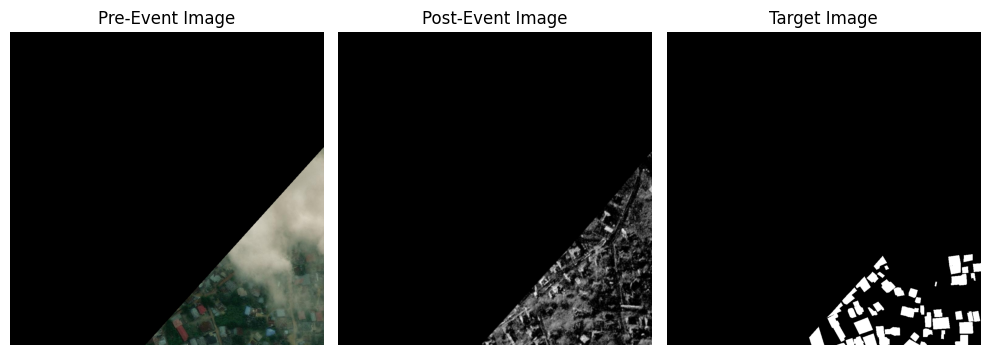

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(10, 5))

IMAGE_INDEX = 0
pre_path = DATA_PATH + "train/pre-event/" + pre_image_parser[IMAGE_INDEX]
post_path = DATA_PATH + "train/post-event/" + post_image_parser[IMAGE_INDEX]
target_path = DATA_PATH + "train/target/" + target_image_parser[IMAGE_INDEX]

with rasterio.open(pre_path) as pre_src:
    arr_1 = pre_src.read()
    print(arr_1.shape)
    if arr_1.shape[0] >= 3:
        pre_img = Image.fromarray(arr_1[:3].transpose(1, 2, 0))
        ax[0].imshow(pre_img)
    else:
        ax[0].imshow(arr_1[0], cmap="gray")
    ax[0].set_title("Pre-Event Image")
    ax[0].axis("off")

with rasterio.open(post_path) as post_src:
    arr_2 = post_src.read()
    arr_2 = gaussian_filter(arr_2, sigma=1)
    print(arr_2.shape)
    if arr_2.shape[0] >= 3:
        post_img = Image.fromarray(arr_2[:3].transpose(1, 2, 0))
        ax[1].imshow(post_img)
        ax[1].set_title("Post-Event Image")
    else:
        ax[1].imshow(arr_2[0], cmap="gray")
        ax[1].set_title("Post-Event Image")
    ax[1].axis("off")

with rasterio.open(target_path) as target_src:
    arr_3 = target_src.read()
    print(arr_3.shape)
    if arr_3.shape[0] >= 3:
        target_img = Image.fromarray(arr_3[:3].transpose(1, 2, 0))
        ax[2].imshow(target_img)
    else:
        ax[2].imshow(arr_3[0], cmap="gray")
    ax[2].set_title("Target Image")
    ax[2].axis("off")
plt.tight_layout()
plt.show()


pre_files = sorted(os.listdir(DATA_PATH + "train/pre-event/"))
post_files = sorted(os.listdir(DATA_PATH + "train/post-event/"))
target_files = sorted(os.listdir(DATA_PATH + "train/target/"))

Loaded patch from Data/train/pre-event/scene_01_000001_building_damage.tif at (x=640, y=512) with valid ratio: 0.4239
Loaded patch from Data/train/post-event/scene_01_000001_building_damage.tif at (x=640, y=512) with valid ratio: 0.3017
Loaded patch from Data/train/target/scene_01_000001_building_damage.tif at (x=640, y=512) with valid ratio: 1.0000


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

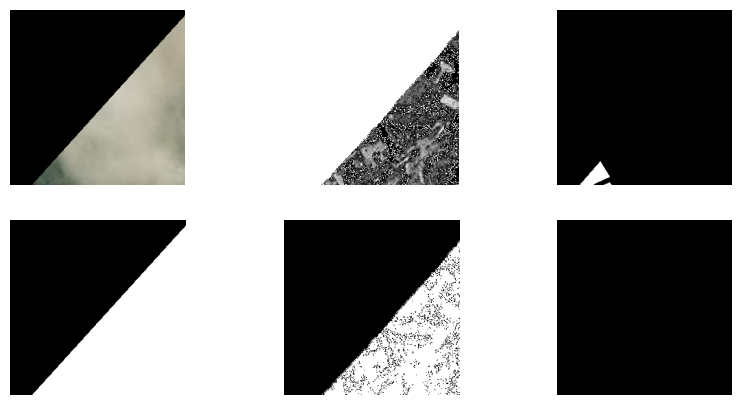

In [13]:
def generate_patch_coordinates(height: int,
                               width: int,
                               patch_size: int,
                               stride: int) -> List[Tuple]:
    coords = []
    for y in range(0, height - patch_size + 1, stride):
        for x in range(0, width - patch_size + 1, stride):
            coords.append((x, y))
    return coords

def load_image_patch(file_path: str,
                     patch_size: int,
                     y: int,
                     x: int):
    with rasterio.open(file_path) as src:
        window = rasterio.windows.Window(x, y, patch_size, patch_size)
        patch = src.read(window=window, masked=True)  # MaskedArray

        valid_mask = ~np.ma.getmaskarray(patch)  # or: ~data.mask
        valid_mask = np.all(valid_mask, axis=0)
        valid_ratio = valid_mask.mean()
        patch = patch.astype(np.uint8)
        patch = np.nan_to_num(patch)
        patch = np.transpose(patch, (1, 2, 0))

        print(f"Loaded patch from {file_path} at (x={x}, y={y}) with valid ratio: {valid_ratio:.4f}")
    
    return patch, valid_mask


coords = generate_patch_coordinates(height=1024, width=1024, patch_size=256, stride=128)
patch,vm1 = load_image_patch(file_path=f"{DATA_PATH}train/pre-event/{pre_files[0]}",
                         patch_size=256,
                         y=coords[33][1],
                         x=coords[33][0])
post_patch, vm2 = load_image_patch(file_path=f"{DATA_PATH}train/post-event/{pre_files[0]}",
                         patch_size=256,
                         y=coords[33][1],
                         x=coords[33][0])
target_patch, vm3 = load_image_patch(file_path=f"{DATA_PATH}train/target/{pre_files[0]}",
                         patch_size=256,
                         y=coords[33][1],
                         x=coords[33][0])

figs, ax = plt.subplots(2, 3, figsize=(10, 5))
ax[0][0].imshow(patch, cmap="gray")
ax[0][0].axis("off")
ax[0][1].imshow(post_patch, cmap="gray")
ax[0][1].axis("off")
ax[0][2].imshow(target_patch, cmap="gray")
ax[0][2].axis("off")
ax[1][0].imshow(vm1, cmap="gray")
ax[1][0].axis("off")
ax[1][1].imshow(vm2, cmap="gray")
ax[1][1].axis("off")
ax[1][2].imshow(vm3, cmap="gray")
ax[1][2].axis("off")


In [85]:
len(coords)

49